In [1]:
from scipy.io import loadmat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import xgboost as xgb

def plot_test_error_vs_trees(model, D_test, y_test, title):
    errors = []
    for i in range(1, model.best_iteration+1):
        preds = model.predict(D_test, iteration_range=(0,i))
        acc = accuracy_score(y_test, preds.astype(int))
        errors.append(1 - acc) #test error
    
    plt.figure(figsize=(6,4))
    plt.plot(range(1, model.best_iteration+1), errors)
    plt.xlabel("Number of Trees")
    plt.ylabel("Test Error")
    plt.title(title)
    plt.grid(True)
    plt.show

[0]	train-merror:0.24487	eval-merror:0.24940
[1]	train-merror:0.18556	eval-merror:0.19080
[2]	train-merror:0.16349	eval-merror:0.16880
[3]	train-merror:0.14795	eval-merror:0.15340
[4]	train-merror:0.13758	eval-merror:0.14300
[5]	train-merror:0.13256	eval-merror:0.13620
[6]	train-merror:0.12756	eval-merror:0.13140
[7]	train-merror:0.12375	eval-merror:0.12780
[8]	train-merror:0.11976	eval-merror:0.12560
[9]	train-merror:0.11511	eval-merror:0.12220
[10]	train-merror:0.11231	eval-merror:0.12080
[11]	train-merror:0.10971	eval-merror:0.11820
[12]	train-merror:0.10651	eval-merror:0.11540
[13]	train-merror:0.10480	eval-merror:0.11380
[14]	train-merror:0.10231	eval-merror:0.11020
[15]	train-merror:0.10011	eval-merror:0.10660
[16]	train-merror:0.09809	eval-merror:0.10340
[17]	train-merror:0.09549	eval-merror:0.10140
[18]	train-merror:0.09418	eval-merror:0.10120
[19]	train-merror:0.09211	eval-merror:0.10000
[20]	train-merror:0.09058	eval-merror:0.09800
[21]	train-merror:0.08875	eval-merror:0.0964

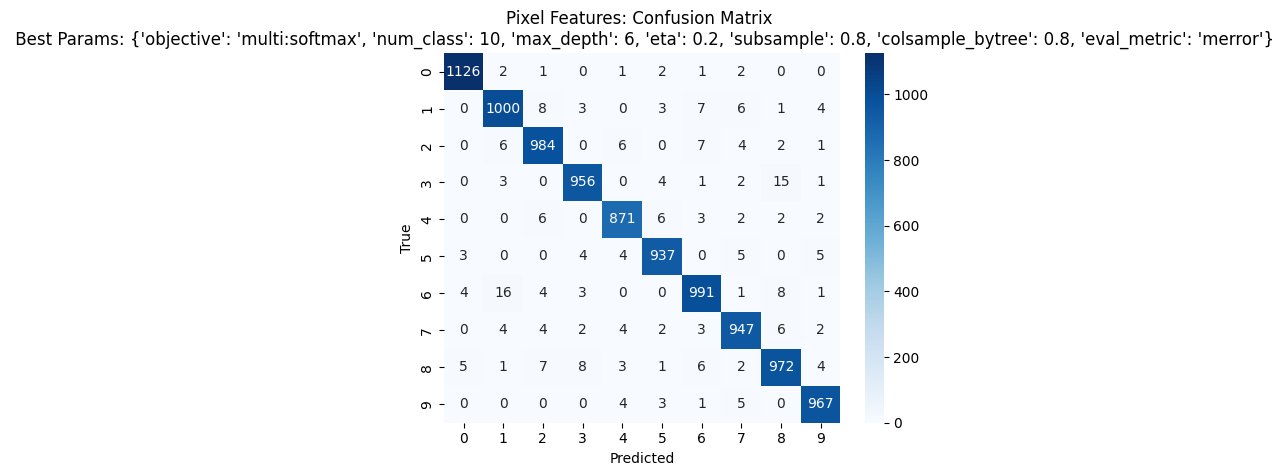

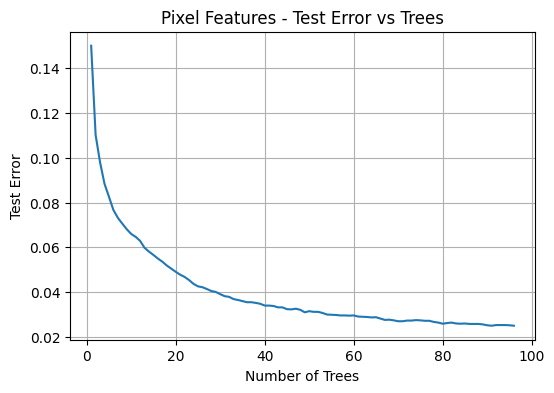

In [ ]:
data = loadmat('data/MNIST.mat')

# print(data.keys())

N = 60000
num_train = 55000
num_val = 5000

np.random.seed(40)

best_score = 0
best_params = None

indices = np.random.permutation(60000)

train_indices = indices[0:num_train]
val_indices = indices[num_train:]

X = data['train_fea']
Y = data['train_gnd']

x_t = X[train_indices]
y_t = Y[train_indices].ravel() - 1

x_v = X[val_indices]
y_v = Y[val_indices].ravel() - 1 

D_train = xgb.DMatrix(x_t, label = y_t)
D_val = xgb.DMatrix(x_v, label = y_v)
watchlist = [(D_train, 'train'),(D_val, 'eval')]

for max_depth in [4,6]:
    for eta in [0.1, 0.2]:
        for subsample in [0.8,]:
            for colsample in [0.8]:
                



                params = {
                    'objective': 'multi:softmax',
                    'num_class': 10,
                    'max_depth': max_depth,
                    'eta': eta,
                    'subsample': subsample,
                    'colsample_bytree': colsample,
                    'eval_metric': 'merror'
                }



                model = xgb.train(
                    params,
                    D_train,
                    num_boost_round=100,
                    evals=watchlist,
                    early_stopping_rounds=50
                )

                # 3. Get validation accuracy
                val_preds = model.predict(D_val)
                val_acc = accuracy_score(val_preds, y_v)

                # 4. Update best parameters if accuracy improved
                if val_acc > best_score:
                    best_score = val_acc
                    best_params = params
                    best_model = model
                    print(f"New best validation accuracy: {best_score:.4f}")


print("Best parameter (Pixel): ", best_params)
print("Best score (Pixel): ", best_score)

#Evaluate in test set
X_test_pixel = data['test_fea']
Y_test_pixel = data['test_gnd'].ravel() -1

D_test_pixel = xgb.DMatrix(X_test_pixel, label=Y_test_pixel)

test_preds_pixel = best_model.predict(D_test_pixel)
test_acc_pixel = accuracy_score(Y_test_pixel, test_preds_pixel.astype(int))
print("Pixel Features Test Accuracy:", test_acc_pixel)

#Print the confusion matrix

cm_pixel = confusion_matrix(Y_test_pixel, test_preds_pixel.astype(int))
plt.Figure(figsize=(8,6))
sns.heatmap(cm_pixel, annot=True, fmt='d', cmap='Blues')
plt.title(f"Pixel Features: Confusion Matrix \n Best Params: {best_params}")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

plot_test_error_vs_trees(best_model, D_test_pixel, Y_test_pixel, "Pixel Features - Test Error vs Trees")


dict_keys(['__header__', '__version__', '__globals__', 'test_fea', 'test_gnd', 'train_fea', 'train_gnd'])
Training with max_depth=4, eta=0.1, subsample=0.8, colsample=0.8
[0]	train-merror:0.11333	eval-merror:0.11700
[1]	train-merror:0.07067	eval-merror:0.07760
[2]	train-merror:0.05955	eval-merror:0.06300
[3]	train-merror:0.05478	eval-merror:0.05760
[4]	train-merror:0.05084	eval-merror:0.05340
[5]	train-merror:0.04735	eval-merror:0.04800
[6]	train-merror:0.04573	eval-merror:0.04800
[7]	train-merror:0.04455	eval-merror:0.04600
[8]	train-merror:0.04316	eval-merror:0.04240
[9]	train-merror:0.04140	eval-merror:0.04060
[10]	train-merror:0.03907	eval-merror:0.04060
[11]	train-merror:0.03764	eval-merror:0.03860
[12]	train-merror:0.03633	eval-merror:0.03820
[13]	train-merror:0.03576	eval-merror:0.03720
[14]	train-merror:0.03458	eval-merror:0.03700
[15]	train-merror:0.03396	eval-merror:0.03640
[16]	train-merror:0.03313	eval-merror:0.03720
[17]	train-merror:0.03215	eval-merror:0.03680
[18]	train-

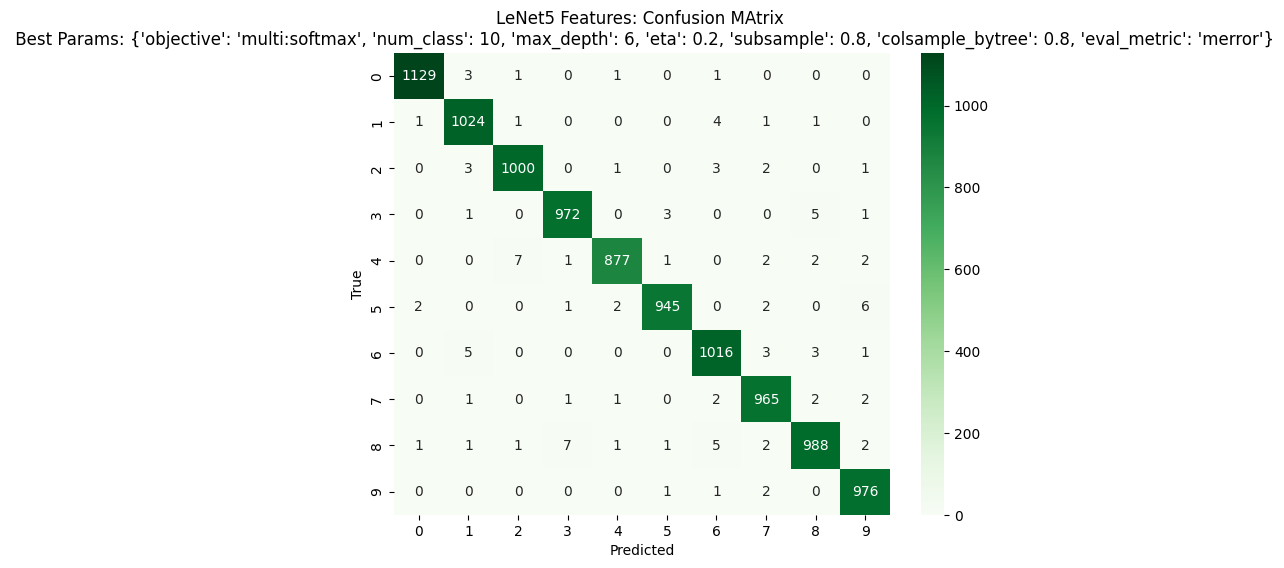

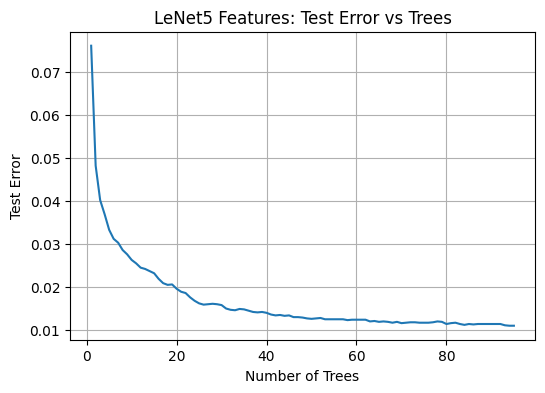

In [5]:
dataLN = loadmat('data/MNIST-LeNet5.mat')

print(dataLN.keys())

X_LN= dataLN['train_fea']
Y_LN = dataLN['train_gnd']

#Divide data into training and validation sets
N = 60000
train_LN = 55000
val_LN = 5000

np.random.seed(40)

indices = np.random.permutation(N)

train_indices_LN = indices[:train_LN]
val_indices_LN = indices[train_LN:]

x_t_LN = X_LN[train_indices_LN]
y_t_LN = Y_LN[train_indices_LN].ravel() -1

x_v_LN = X_LN[val_indices_LN]
y_v_LN = Y_LN[val_indices_LN].ravel() -1

#Convert to DMatrix for XGBoost
D_train_LN = xgb.DMatrix(x_t_LN, label=y_t_LN)
D_val_LN = xgb.DMatrix(x_v_LN, label=y_v_LN)
watchlist_LN = [(D_train_LN, 'train'), (D_val_LN, 'eval')]

#Same as pixels: Hyperparameter grid search
best_score_LN = 0
best_params_LN = None

for max_depth_LN in [4,6]:
    for eta_LN in [0.1, 0.2]:
        for subsample_LN in [0.8]:
            for colsample_LN in [0.8]:
                print(f"Training with max_depth={max_depth_LN}, eta={eta_LN}, subsample={subsample_LN}, colsample={colsample_LN}")

                params_LN = {
                    'objective': 'multi:softmax',
                    'num_class': 10,
                    'max_depth': max_depth_LN,
                    'eta': eta_LN,
                    'subsample': subsample_LN,
                    'colsample_bytree': colsample_LN,
                    'eval_metric': 'merror'
                }

                model = xgb.train(
                    params_LN,
                    D_train_LN,
                    num_boost_round = 100,
                    evals = watchlist_LN,
                    early_stopping_rounds = 50 
                )

                val_preds_LN = model.predict(D_val_LN)
                val_acc_LN = accuracy_score(y_v_LN, val_preds_LN.astype(int))

                if val_acc_LN > best_score_LN:
                    best_score_LN = val_acc_LN
                    best_params_LN = params_LN
                    best_model_LN = model
                    print(f"New best score: {best_score_LN} with params: {best_params_LN}")



print("Best parameter (LeNet5 features):", best_params_LN)
print("Best score (LeNet5 features):", best_score_LN)

X_test_LN = dataLN['test_fea']
Y_test_LN = dataLN['test_gnd'].ravel() - 1
D_test_LN = xgb.DMatrix(X_test_LN, label=Y_test_LN)

test_preds_LN = best_model_LN.predict(D_test_LN)
test_acc_LN = accuracy_score(Y_test_LN, test_preds_LN.astype(int))
print("LeNet5 Features Test Accuracy:", test_acc_LN)

#Confusion matrix(LN)
cm_LN = confusion_matrix(Y_test_LN, test_preds_LN.astype(int))
plt.figure(figsize=(8,6))
sns.heatmap(cm_LN, annot=True, fmt='d', cmap='Greens')
plt.title(f"LeNet5 Features: Confusion MAtrix \n Best Params: {best_params_LN}")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show

plot_test_error_vs_trees(best_model_LN, D_test_LN, Y_test_LN, "LeNet5 Features: Test Error vs Trees")


In [ ]:
best_model.save_model('best_xgb_pixel.json')

best_model_LN.save_model('best_xgb_lenet.json')
